In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

In [3]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.443130,170.404495,41.931015,54.717331,76.912788,64.291084,540.298584,102.615837,341.583496,75.843269,...,154.084091,147.359787,392.184113,29.220690,453.210388,399.926666,230.069702,46.069378,45.858704,55.607395
2022-01-04,176.178375,167.522003,43.574478,55.142239,77.167366,67.079926,537.934082,104.482994,343.629364,79.329262,...,154.306824,147.875412,387.097260,30.639351,453.058594,383.196655,229.634155,47.903797,45.018562,57.699013
2022-01-05,171.492111,164.356995,42.839005,54.500534,77.485611,65.929520,524.290894,105.162735,340.098419,77.873291,...,154.832367,148.544815,375.205292,30.639351,444.358887,362.706665,224.653397,47.486065,45.627262,58.416637
2022-01-06,168.629333,163.253998,43.701607,56.286877,76.976425,68.404610,524.176575,106.057594,338.510345,79.470711,...,154.867966,147.296448,374.941589,31.367102,443.941498,354.899994,224.596619,48.702961,45.500450,59.790630
2022-01-07,168.795975,162.554001,44.654987,57.041309,76.776390,70.278343,511.191406,107.580551,338.435760,81.667137,...,155.063965,147.215042,370.879913,32.269878,442.186310,342.320007,223.573944,49.738220,45.934788,60.280724


# Get the Log Returns of the Stocks (because we are using the Markowitz Portfolio Theory)

We adopt Markowitz Portfolio Theory as the conceptual framework for our analysis. As such, our emphasis is on modeling the returns of the assets because this theory focuses on portfolio returns, their expected values, and covariances. Consistent with the mean‑variance portfolio framework, we define the log returns as
$$r_{t, i} = \log{P_{t, i}} - \log{P_{t-1, i}},$$
where $P_{t, i}$ denotes the price of asset $i$ at time $t$. We specifically take the log return to ensure that the returns are time-additive, stationary, and suitable for multivariate modeling, which simplifies the subsequent analysis. [(Ślusarczyk and Ślepaczuk, 2025)]().

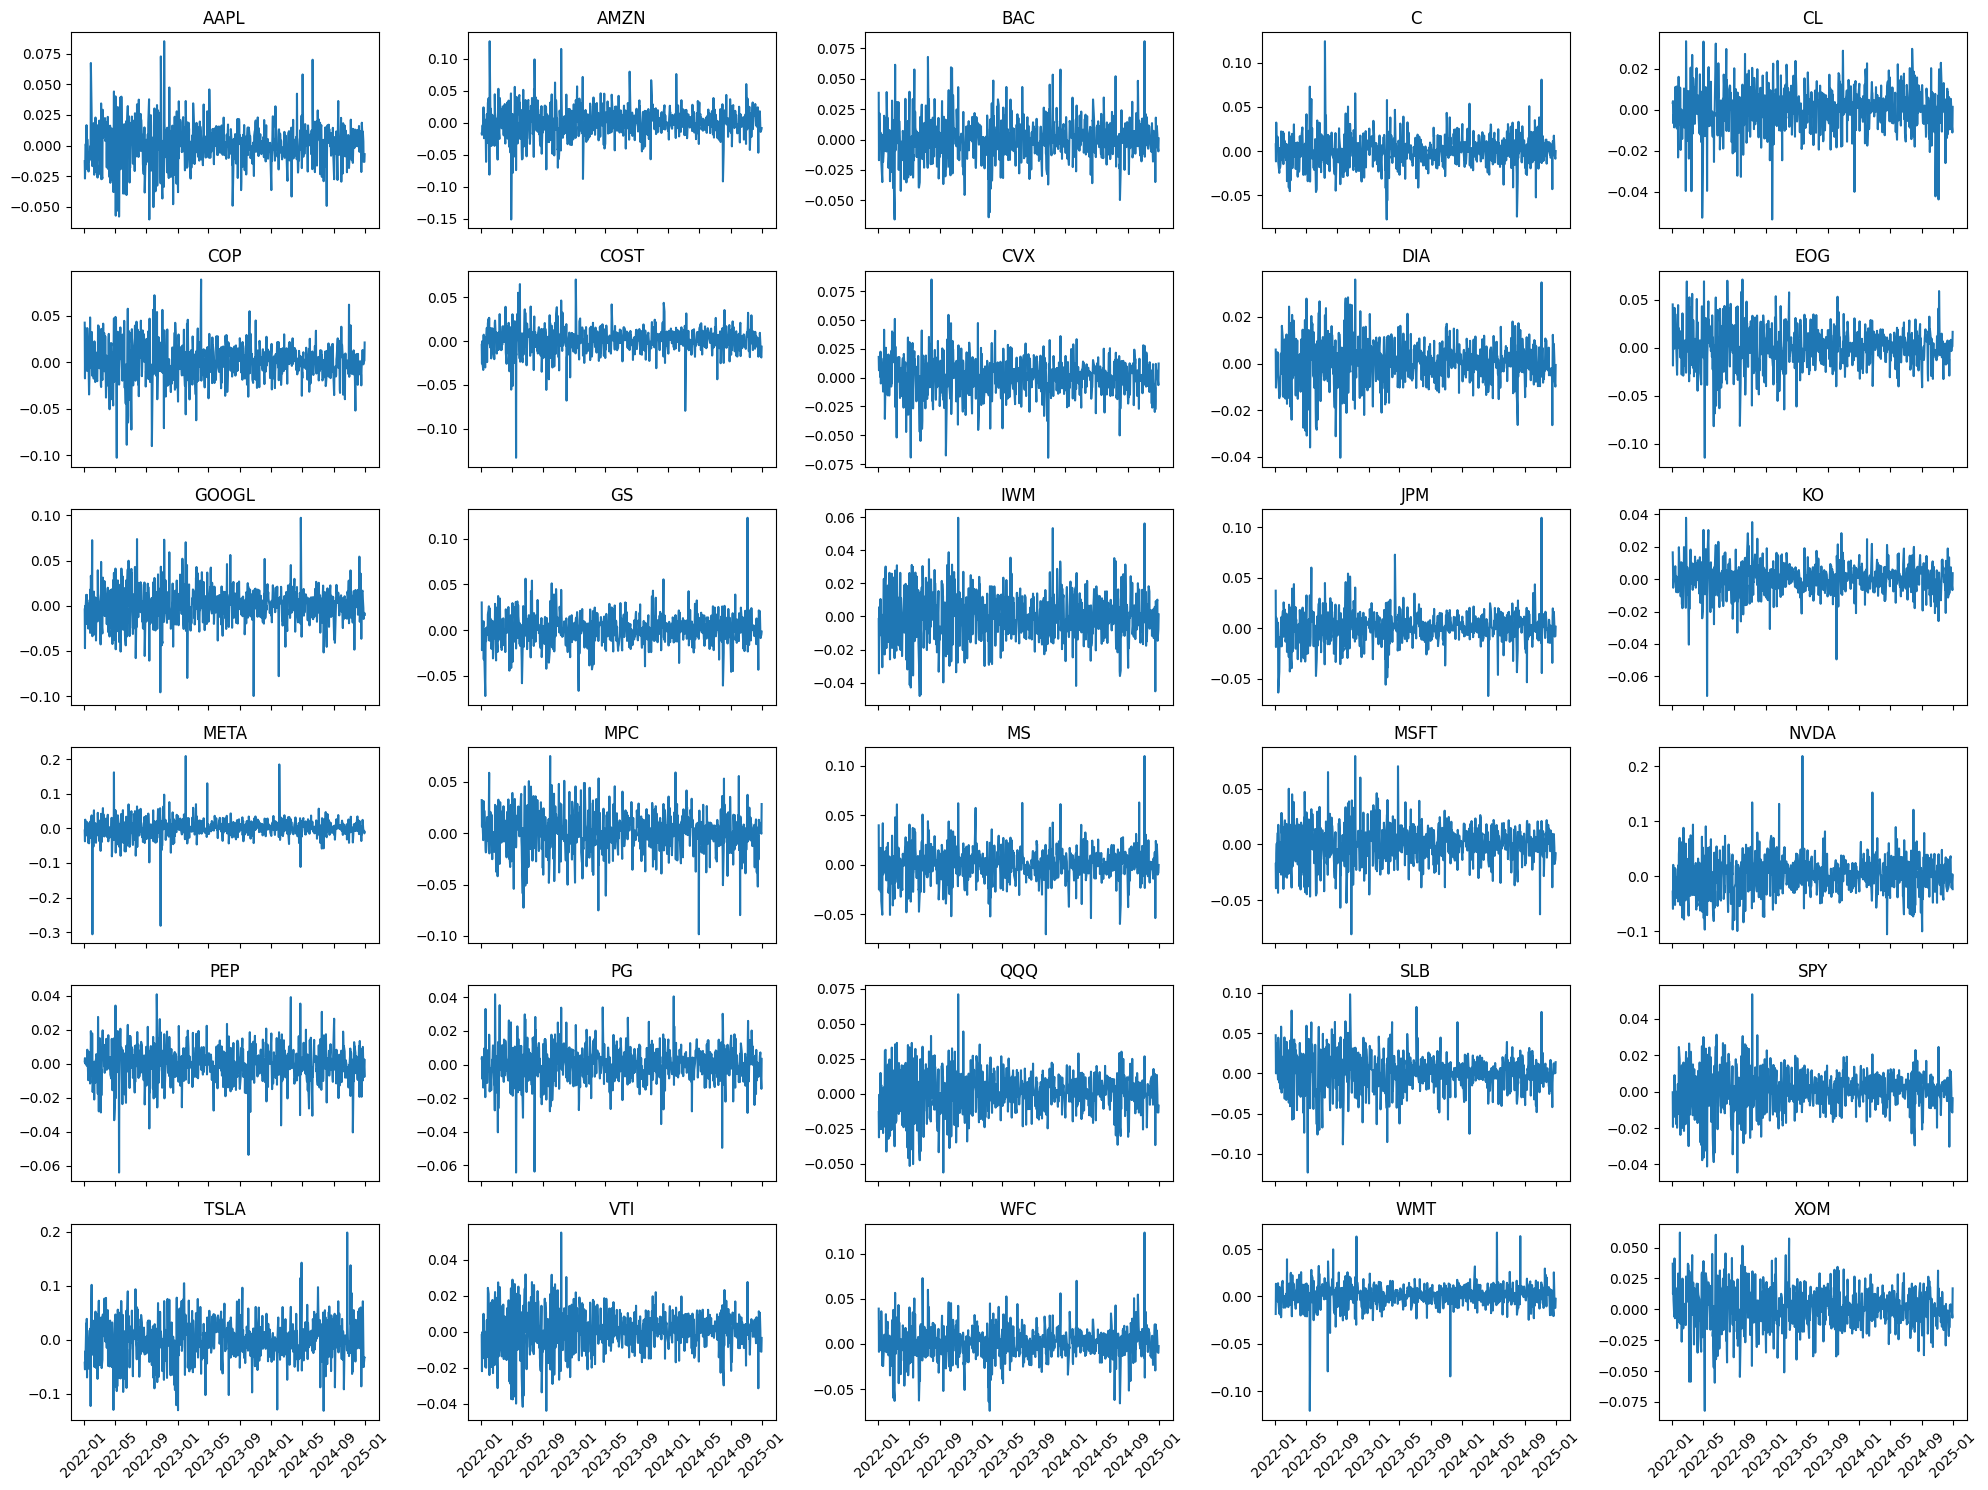

In [13]:
# Get the log returns
log_returns = np.log(close_historical_df).diff().dropna()

fig, axes = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axes.flatten(), log_returns.columns):
    ax.plot(log_returns[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [14]:
log_returns

Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.012773,-0.017060,0.038446,0.007736,0.003304,0.042464,-0.004386,0.018032,0.005971,0.044938,...,0.001444,0.003493,-0.013055,0.047408,-0.000335,-0.042733,-0.001895,0.039046,-0.018490,0.036924
2022-01-05,-0.026960,-0.019074,-0.017023,-0.011706,0.004116,-0.017299,-0.025689,0.006485,-0.010329,-0.018524,...,0.003400,0.004517,-0.031203,0.000000,-0.019389,-0.054954,-0.021929,-0.008758,0.013430,0.012361
2022-01-06,-0.016834,-0.006734,0.019936,0.032251,-0.006593,0.036854,-0.000218,0.008473,-0.004680,0.020306,...,0.000230,-0.008439,-0.000703,0.023474,-0.000940,-0.021758,-0.000253,0.025304,-0.002783,0.023248
2022-01-07,0.000988,-0.004297,0.021581,0.013314,-0.002602,0.027023,-0.025085,0.014258,-0.000220,0.027263,...,0.001265,-0.000553,-0.010892,0.028375,-0.003961,-0.036090,-0.004564,0.021034,0.009501,0.008163
2022-01-10,0.000116,-0.006592,-0.005096,0.003793,-0.008683,0.004825,-0.032952,0.000640,-0.004204,-0.001019,...,0.000517,-0.013735,0.000658,0.002566,-0.001245,0.029891,-0.001738,0.010534,-0.001934,-0.005970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011413,0.017573,0.011103,0.017476,0.005209,0.007546,0.009336,0.006067,0.008382,0.008144,...,0.009997,0.004925,0.013469,0.012535,0.011054,0.070991,0.010556,0.014775,0.025462,0.000940
2024-12-26,0.003171,-0.008770,0.003823,0.004917,-0.000216,-0.002268,-0.002799,0.000973,0.001640,-0.003482,...,-0.002424,0.007196,-0.000680,0.000000,0.000067,-0.017787,0.000572,0.002372,0.001186,0.000845
2024-12-27,-0.013331,-0.014641,-0.004725,-0.004917,-0.006081,0.000310,-0.017344,0.000139,-0.007437,-0.000083,...,0.002947,-0.003709,-0.013382,0.001854,-0.010582,-0.050745,-0.010890,-0.009099,-0.012253,-0.000094


# Baselines

# ARIMA


# VAR